In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('D:\\datafile\\furniture_data.csv')
df.head()

,Product,Sale Price,Cost per Product,Quantity,Total Revenue
0,Sofa,800,600,32,25600
1,Chair,300,200,12,3600
2,Table,500,300,41,20500
3,Bed,1000,700,23,23000
4,Wardrobe,800,600,19,15200


In [18]:
len(df)

16

In [19]:
df.Product.duplicated().sum()

np.int64(6)

In [20]:
df_dup = df.pivot_table(index = ['Product'], aggfunc = 'size')
print(df_dup)

Product
Bed             1
Bookshelf       2
Chair           1
Coffee Table    2
Dresser         2
Ottoman         2
Rug             2
Sofa            1
Table           1
Wardrobe        2
dtype: int64


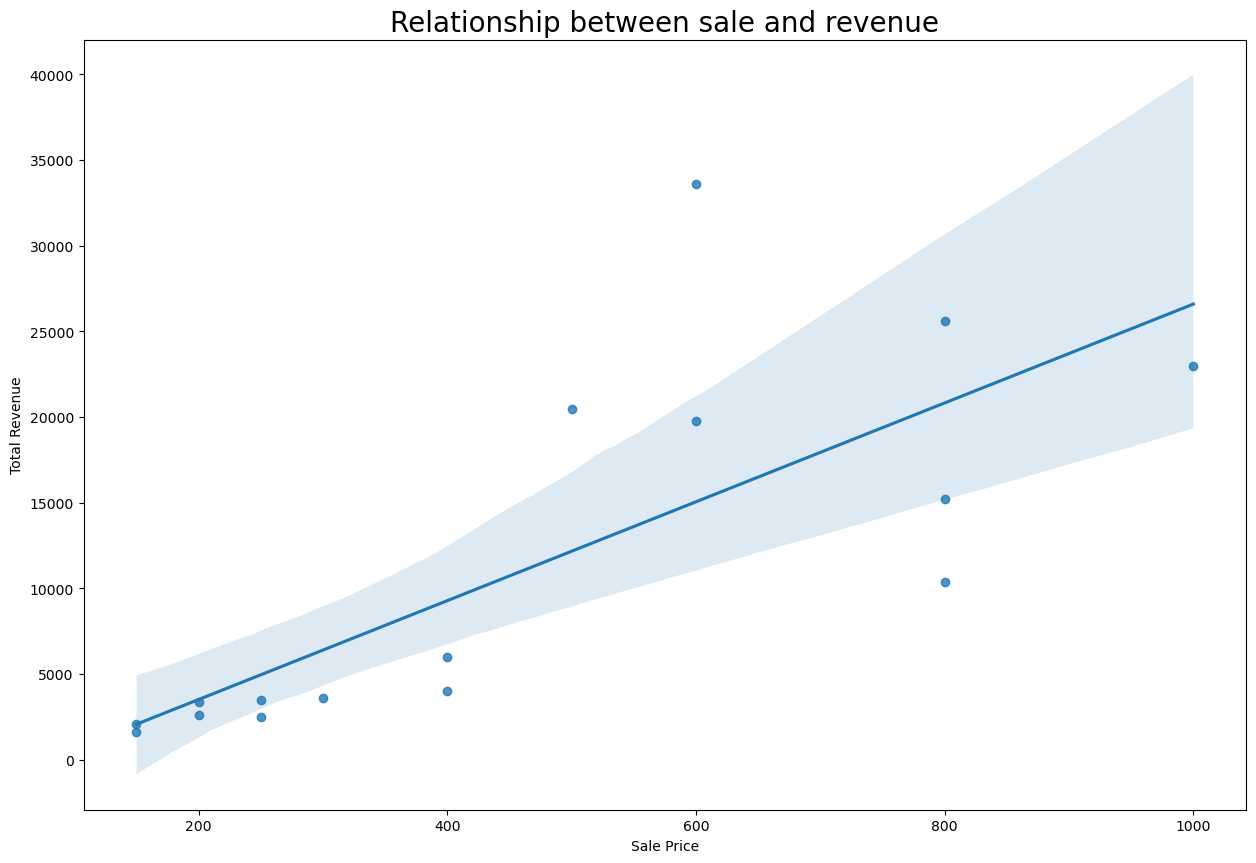

In [21]:
import seaborn as sns

fig = plt.figure(figsize=(15,10))

sns.regplot(x = df['Sale Price'], y =df['Total Revenue'], data = df)

plt.title('Relationship between sale and revenue', fontsize = 20)

plt.show()
            

In [22]:
df_data = df.groupby('Product')['Total Revenue'].sum()
df_data


Product
Bed             23000
Bookshelf       10000
Chair            3600
Coffee Table     6000
Dresser         53400
Ottoman          6000
Rug              3750
Sofa            25600
Table           20500
Wardrobe        25600
Name: Total Revenue, dtype: int64

In [23]:
diff = df_data.Wardrobe - df_data.Bed
print(f'Diffence between wardrobe and sales {diff}')

Diffence between wardrobe and sales 2600


In [24]:
df.head()

,Product,Sale Price,Cost per Product,Quantity,Total Revenue
0,Sofa,800,600,32,25600
1,Chair,300,200,12,3600
2,Table,500,300,41,20500
3,Bed,1000,700,23,23000
4,Wardrobe,800,600,19,15200


In [27]:
df['total cost'] = df['Cost per Product'] * df['Quantity']
df.head()

,Product,Sale Price,Cost per Product,Quantity,Total Revenue,total cost
0,Sofa,800,600,32,25600,19200
1,Chair,300,200,12,3600,2400
2,Table,500,300,41,20500,12300
3,Bed,1000,700,23,23000,16100
4,Wardrobe,800,600,19,15200,11400


In [26]:
df.insert(4, 'total cost', total cost)
df.head()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3792595552.py, line 1)

In [ ]:
df.head()

In [28]:
df['profit'] = df['Total Revenue'] - df['total cost']
df.head()

,Product,Sale Price,Cost per Product,Quantity,Total Revenue,total cost,profit
0,Sofa,800,600,32,25600,19200,6400
1,Chair,300,200,12,3600,2400,1200
2,Table,500,300,41,20500,12300,8200
3,Bed,1000,700,23,23000,16100,6900
4,Wardrobe,800,600,19,15200,11400,3800


In [29]:
group_df = df.groupby('Product')[['Total Revenue','profit']].sum()
group_df

,Total Revenue,profit
Product,,
Bed,23000,6900
Bookshelf,10000,2500
Chair,3600,1200
Coffee Table,6000,2400
Dresser,53400,8900
Ottoman,6000,3000
Rug,3750,1875
Sofa,25600,6400
Table,20500,8200


In [30]:
group_df['Profit_margin'] = (group_df['profit']/ group_df['Total Revenue'])*100
group_df.head()

,Total Revenue,profit,Profit_margin
Product,,,
Bed,23000,6900,30.000000
Bookshelf,10000,2500,25.000000
Chair,3600,1200,33.333333
Coffee Table,6000,2400,40.000000
Dresser,53400,8900,16.666667


In [31]:
group_df.sort_values(by ='Profit_margin', ascending = True)
group_df.head()

,Total Revenue,profit,Profit_margin
Product,,,
Bed,23000,6900,30.000000
Bookshelf,10000,2500,25.000000
Chair,3600,1200,33.333333
Coffee Table,6000,2400,40.000000
Dresser,53400,8900,16.666667


In [32]:
group_df = group_df.drop('Profit margin', axis = 1)
group_df

KeyError: "['Profit margin'] not found in axis"

In [33]:
group_df.sort_values(by = 'Profit_margin', ascending = True)
group_df.head(1)

,Total Revenue,profit,Profit_margin
Product,,,
Bed,23000,6900,30.0
